In [1]:
import torch, random, numpy as np
import matplotlib.pyplot as plt

from mnist_datamodule import MNISTDataModule
from mnist_mlp_classifier import MNISTMLP

In [2]:
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

/home/logus/env/iscte/mnist_digits/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [3]:
CKPT = "checkpoints/mnist_mlp_best.ckpt"
BATCH_SIZE = 256
NUM_WORKERS = 2
N_SAMPLES = 32
N_WRONG = 32

Test accuracy: 0.9937  (9937/10000)
First 20 predictions: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4]


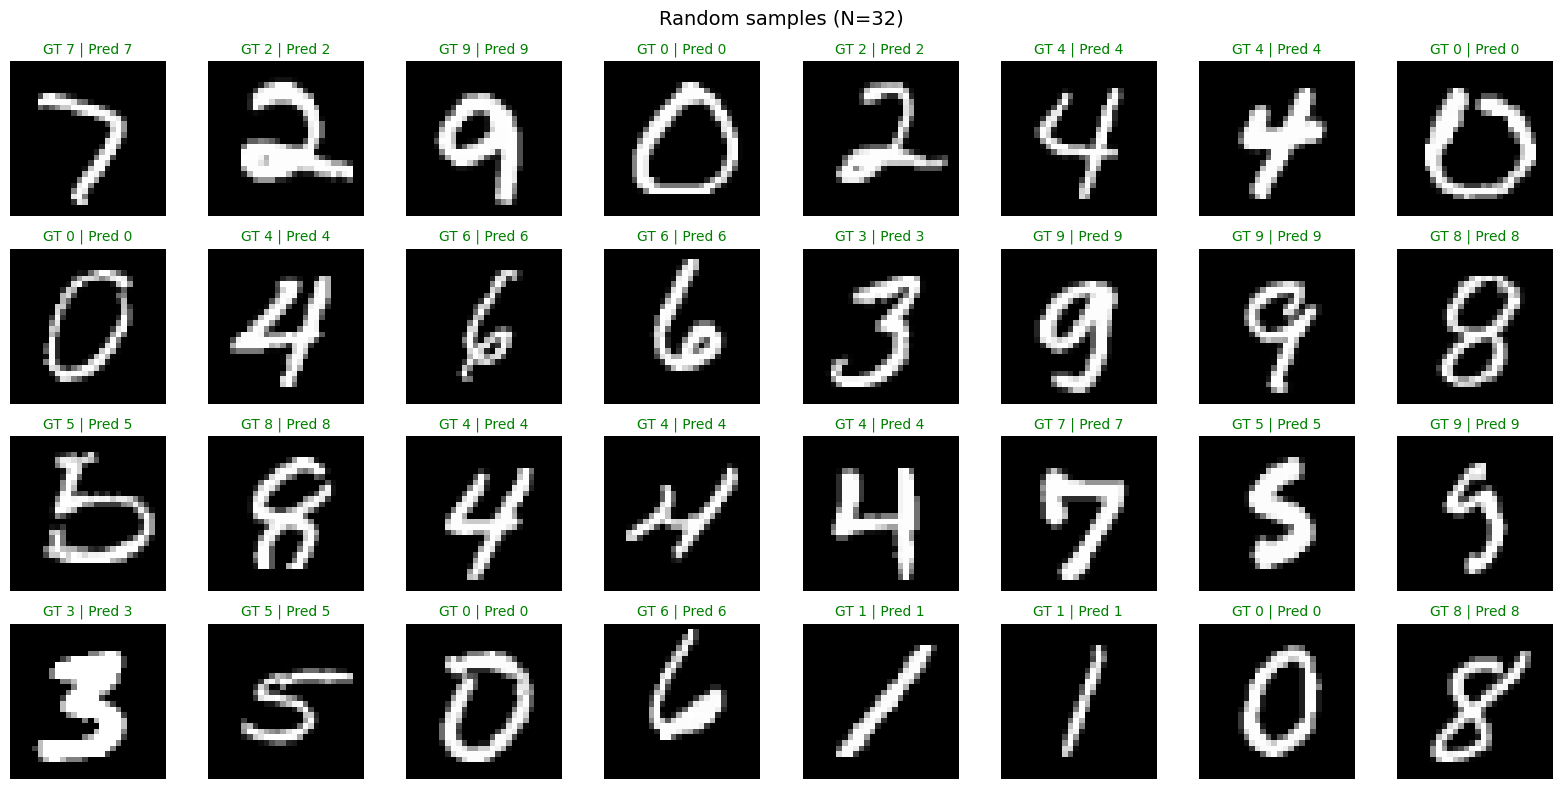

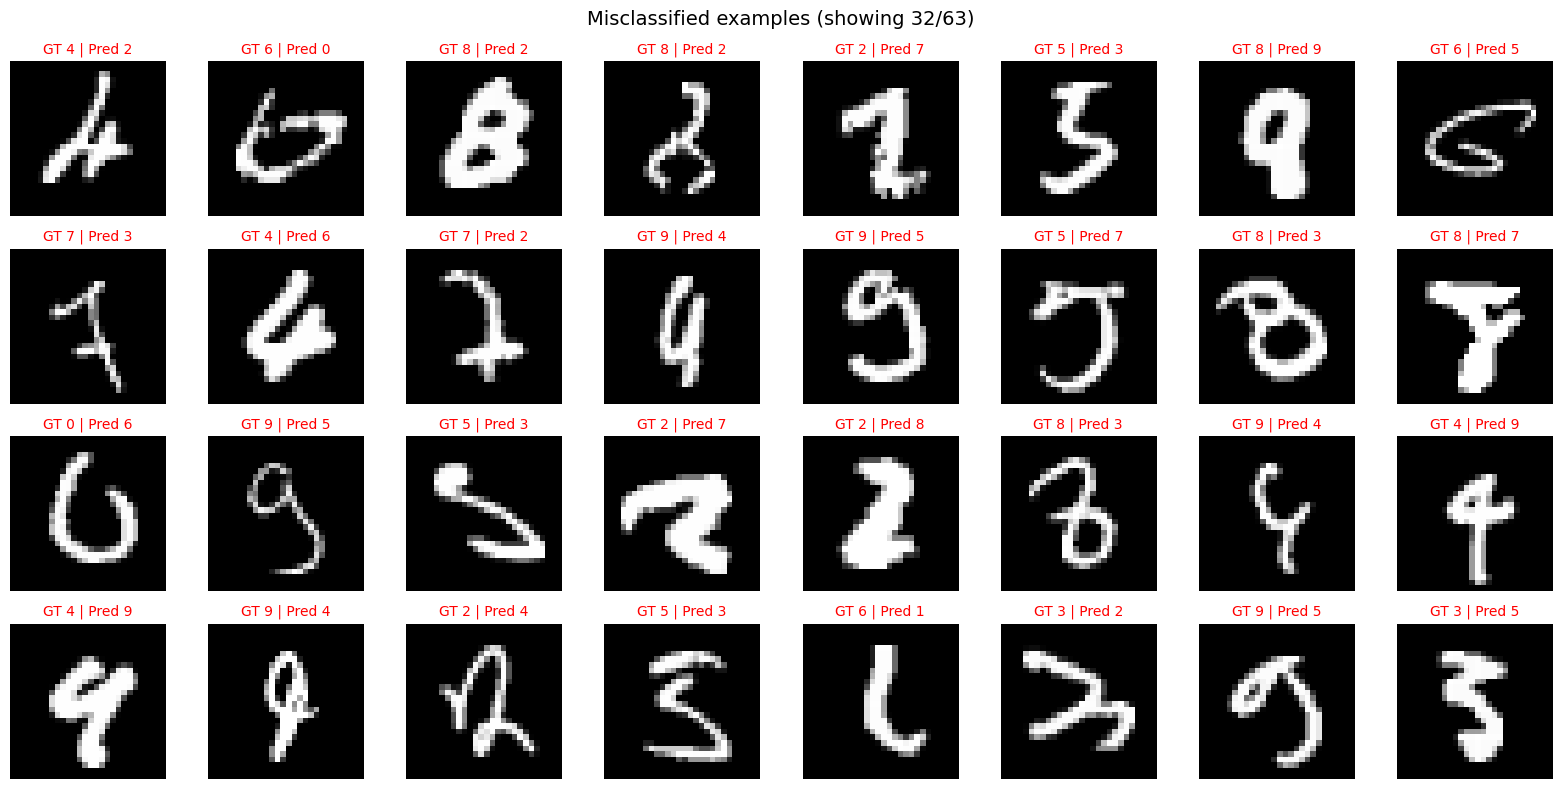

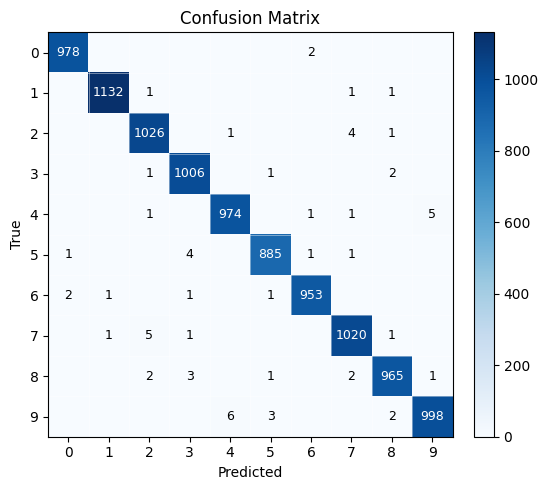

Saved: misclassified_grid.png and confusion_matrix.png (in current working directory).


In [4]:
# 1) Load model and dataloader
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MNISTMLP.load_from_checkpoint(CKPT).eval().to(device)

dm = MNISTDataModule(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=(device=="cuda"))
dm.setup(stage="test")
loader = dm.test_dataloader()

# 2) Run inference over the full test set
images, y_true, y_pred = [], [], []
with torch.no_grad():
	for x, y in loader:
		logits = model(x.to(device))          # [B, 10]
		p  = logits.argmax(dim=1).cpu()       # [B]
		images.append(x.cpu())                # keep CPU tensors for plotting
		y_true.append(y.cpu())
		y_pred.append(p)

images = torch.cat(images, dim=0)            # [N, 1, 28, 28]
y_true = torch.cat(y_true, dim=0)            # [N]
y_pred = torch.cat(y_pred, dim=0)            # [N]
acc = (y_true == y_pred).float().mean().item()
print(f"Test accuracy: {acc:.4f}  ({(y_true==y_pred).sum().item()}/{len(y_true)})")
print("First 20 predictions:", y_pred[:20].tolist())

# 3) Helper: plot a grid with colored titles
def show_grid(idx_list, title, savepath=None, ncols=8):
	n = len(idx_list)
	ncols = min(ncols, n) if n > 0 else 1
	nrows = int(np.ceil(n / ncols))
	plt.figure(figsize=(ncols*2.0, nrows*2.0))
	for i, idx in enumerate(idx_list):
		ax = plt.subplot(nrows, ncols, i+1)
		ax.imshow(images[idx, 0], cmap="gray", interpolation="nearest")
		gt = int(y_true[idx].item()); pr = int(y_pred[idx].item())
		color = "green" if gt == pr else "red"
		ax.set_title(f"GT {gt} | Pred {pr}", color=color, fontsize=10)
		ax.axis("off")
	plt.suptitle(title, fontsize=14)
	plt.tight_layout()
	#if savepath:
	#	plt.savefig(savepath, dpi=150, bbox_inches="tight")
	plt.show()

# 4) Random sample grid
all_indices = list(range(len(y_true)))
random.shuffle(all_indices)
show_grid(all_indices[:N_SAMPLES], title=f"Random samples (N={N_SAMPLES})")

# 5) Misclassified-only grid
wrong_idx = (y_true != y_pred).nonzero(as_tuple=False).view(-1).tolist()
if len(wrong_idx):
	show_grid(wrong_idx[:N_WRONG], title=f"Misclassified examples (showing {min(N_WRONG,len(wrong_idx))}/{len(wrong_idx)})",
	          savepath="misclassified_grid.png")
else:
	print("No misclassifications found.")

# 6) Confusion matrix (no seaborn needed)
num_classes = 10
cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
for t, p in zip(y_true, y_pred):
	cm[t, p] += 1

cm_np = cm.cpu().numpy() if hasattr(cm, "cpu") else np.asarray(cm)

cmap_name = "Blues"   # try: "Greens", "Oranges", "viridis", "magma"
plt.figure(figsize=(6, 5))
im = plt.imshow(cm_np, cmap=cmap_name, vmin=0)  # vmin=0 -> light background for zeros
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar(im, fraction=0.046, pad=0.04)

ticks = np.arange(num_classes)
plt.xticks(ticks, ticks)
plt.yticks(ticks, ticks)

# Light grid to separate cells (keeps heatmap visible)
ax = plt.gca()
ax.set_xticks(ticks - 0.5, minor=True)
ax.set_yticks(ticks - 0.5, minor=True)
ax.grid(which="minor", color="w", linewidth=0.5, alpha=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# Write counts with auto-contrast text color
mx = cm_np.max() if cm_np.size else 1
for i in range(num_classes):
	for j in range(num_classes):
		val = int(cm_np[i, j])
		if val == 0:
			continue
		# normalize cell intensity to decide text color
		norm = val / (mx + 1e-9)
		txt_color = "white" if norm > 0.5 else "black"
		plt.text(j, i, str(val), ha="center", va="center", color=txt_color, fontsize=9)

plt.tight_layout()
# plt.savefig("confusion_matrix_better.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: misclassified_grid.png and confusion_matrix.png (in current working directory).")